# ❤️ Capstone — Do pico no espectro ao batimento cardíaco
por: **Iury Coelho**

Projetos como o **[RuView](https://github.com/ruvnet/RuView)** transformam WiFi
comum em um sensor capaz de medir **respiração e batimento cardíaco sem contato,
através de paredes**. Parece mágica, mas o coração disso é **processamento de
sinais** — exatamente o que estudamos neste curso.

Quando uma pessoa respira, o peito sobe e desce; o coração bate. Esses
movimentos **modulam** o sinal de rádio que reflete pelo ambiente (o *Channel
State Information*, CSI). Recuperar a respiração e o batimento a partir desse
sinal é um exercício de **filtragem passa-banda** + **Transformada de Fourier**.

Neste notebook fechamos o curso ligando os fundamentos a essa fronteira — sem
hardware, com um sinal sintético realista.

#### Conteúdo
* [1. A física do sinal](#1)
* [2. O problema: tudo misturado](#2)
* [3. Isolando a respiração](#3)
* [4. Isolando o batimento](#4)
* [5. Resultado](#5)
* [6. Da simulação ao mundo real](#6)
* [7. Exercício](#7)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as ss

plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

<a id="1"></a>
## 1. A física do sinal

Vamos sintetizar um sinal parecido com o que um sensor de rádio captaria,
amostrado a $f_s = 50$ Hz por 60 segundos. Ele é a soma de:

| Componente | Frequência | Por quê |
|---|---|---|
| Deriva lenta | ~0,02 Hz | movimento lento do ambiente / variação de canal |
| **Respiração** | **0,30 Hz** (18/min) | peito subindo e descendo |
| **Batimento** | **1,20 Hz** (72 bpm) | coração — bem mais fraco que a respiração |
| Ruído | — | ruído do sensor |

Repare: o batimento tem amplitude **muito menor** que a respiração — por isso
ele "some" no sinal bruto e precisamos de filtragem para revelá-lo.

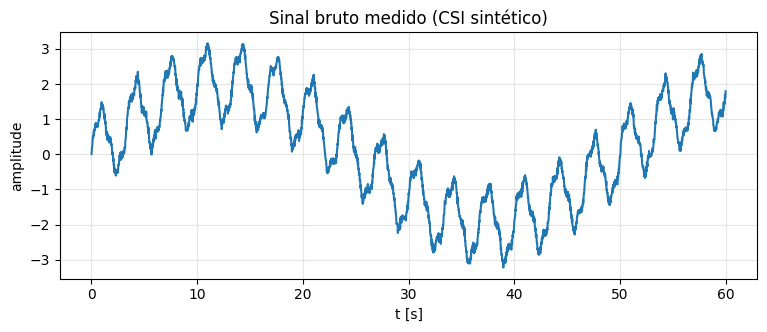

In [2]:
rng = np.random.default_rng(0)
fs = 50.0            # Hz
dur = 60.0           # s  (janela longa = boa resolucao em frequencia)
t = np.arange(0, dur, 1/fs)

F_RESP = 0.30        # Hz  -> 18 respiracoes/min
F_CARD = 1.20        # Hz  -> 72 batimentos/min

respiracao = 1.00 * np.sin(2*np.pi*F_RESP*t)
batimento  = 0.20 * np.sin(2*np.pi*F_CARD*t)     # bem mais fraco
deriva     = 2.00 * np.sin(2*np.pi*0.02*t)       # variacao lenta, forte
ruido      = 0.06 * rng.standard_normal(len(t))

csi = deriva + respiracao + batimento + ruido    # o "sinal medido"

plt.plot(t, csi)
plt.title("Sinal bruto medido (CSI sintético)")
plt.xlabel("t [s]"); plt.ylabel("amplitude"); plt.show()

<a id="2"></a>
## 2. O problema: está tudo misturado

No tempo, o sinal é dominado pela deriva lenta — nem dá para ver a respiração, e
muito menos o batimento. Mas no **domínio da frequência** cada componente vira um
**pico** na sua própria frequência. É isso que torna o problema solúvel.

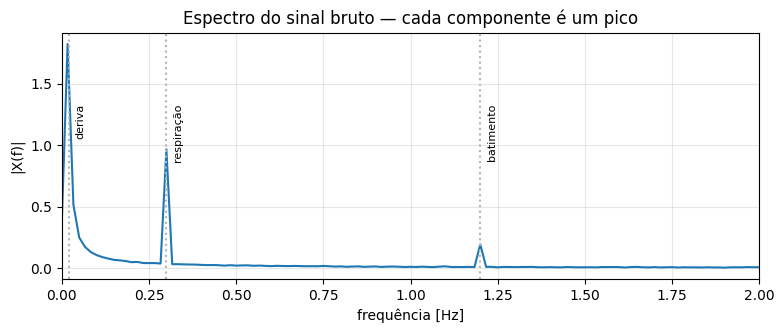

In [3]:
def espectro(x, fs):
    # amplitude de um sinal real via rFFT
    X = np.abs(np.fft.rfft(x)) / len(x) * 2
    f = np.fft.rfftfreq(len(x), 1/fs)
    return f, X

f, X = espectro(csi, fs)
plt.plot(f, X)
plt.xlim(0, 2.0)
for fc, nome in [(0.02, "deriva"), (F_RESP, "respiração"), (F_CARD, "batimento")]:
    plt.axvline(fc, color="0.7", ls=":")
    plt.text(fc + 0.02, plt.ylim()[1]*0.7, nome, rotation=90, va="top", fontsize=8)
plt.title("Espectro do sinal bruto — cada componente é um pico")
plt.xlabel("frequência [Hz]"); plt.ylabel("|X(f)|"); plt.show()

<a id="3"></a>
## 3. Isolando a respiração

A respiração humana fica entre ~0,1 e 0,6 Hz (6–36 por minuto). Um **passa-banda**
nessa faixa rejeita a deriva (abaixo) e o batimento (acima). Depois, a FFT do
sinal filtrado dá a frequência — e a **frequência do pico × 60 = respirações por
minuto**.

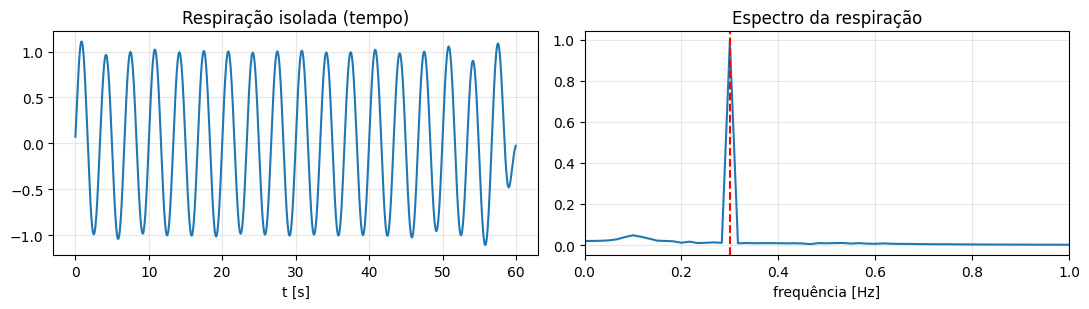

Respiração estimada: 18.0 por minuto


In [4]:
def passa_banda(x, fs, fmin, fmax, ordem=4):
    sos = ss.butter(ordem, [fmin, fmax], btype="band", fs=fs, output="sos")
    return ss.sosfiltfilt(sos, x)

def bpm_do_pico(x, fs, fmin, fmax):
    # frequencia dominante (em bpm) dentro da faixa [fmin, fmax]
    f, X = espectro(x, fs)
    faixa = (f >= fmin) & (f <= fmax)
    f_pico = f[faixa][np.argmax(X[faixa])]
    return f_pico * 60.0

resp = passa_banda(csi, fs, 0.1, 0.6)
rpm = bpm_do_pico(resp, fs, 0.1, 0.6)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
a1.plot(t, resp, "C0"); a1.set_title("Respiração isolada (tempo)")
a1.set_xlabel("t [s]"); a1.grid(alpha=.3)
fr, Xr = espectro(resp, fs)
a2.plot(fr, Xr, "C0"); a2.set_xlim(0, 1.0)
a2.axvline(rpm/60, color="r", ls="--"); a2.set_title("Espectro da respiração")
a2.set_xlabel("frequência [Hz]"); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"Respiração estimada: {rpm:.1f} por minuto")

<a id="4"></a>
## 4. Isolando o batimento

O batimento cardíaco fica acima — tipicamente 0,8 a 2,0 Hz (48–120 bpm). O mesmo
truque, em outra banda. Mesmo sendo um sinal **muito mais fraco**, o passa-banda
remove a respiração dominante e a FFT revela o pico cardíaco.

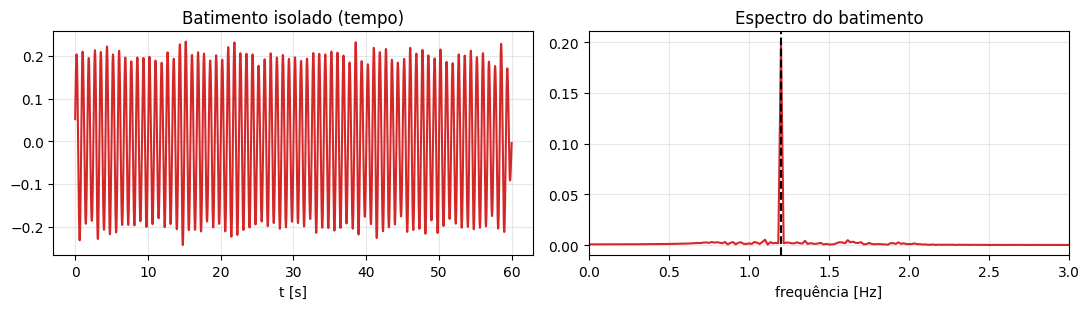

Batimento estimado: 72.0 bpm


In [5]:
card = passa_banda(csi, fs, 0.8, 2.0)
bpm = bpm_do_pico(card, fs, 0.8, 2.0)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
a1.plot(t, card, "C3"); a1.set_title("Batimento isolado (tempo)")
a1.set_xlabel("t [s]"); a1.grid(alpha=.3)
fc_, Xc = espectro(card, fs)
a2.plot(fc_, Xc, "C3"); a2.set_xlim(0, 3.0)
a2.axvline(bpm/60, color="k", ls="--"); a2.set_title("Espectro do batimento")
a2.set_xlabel("frequência [Hz]"); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"Batimento estimado: {bpm:.1f} bpm")

<a id="5"></a>
## 5. Resultado

Recuperamos os dois sinais vitais **sem nunca tocar na pessoa** — só com
filtragem e Fourier sobre um sinal de rádio.

In [6]:
print(f"{'Sinal vital':<14}{'verdadeiro':>12}{'estimado':>12}")
print(f"{'Respiração':<14}{F_RESP*60:>10.0f}/min{rpm:>9.1f}/min")
print(f"{'Batimento':<14}{F_CARD*60:>11.0f} bpm{bpm:>8.1f} bpm")

Sinal vital     verdadeiro    estimado
Respiração            18/min     18.0/min
Batimento              72 bpm    72.0 bpm


<a id="6"></a>
## 6. Da simulação ao mundo real

Foi exatamente este o caminho — só que com um sinal sintético no lugar do CSI de
verdade. Em sistemas reais como o **RuView**:

- o **CSI** vem de um chip WiFi (um ESP32 de ~US$9 já serve);
- há **muito mais ruído**, múltiplos caminhos de reflexão e movimento corporal,
  então entram etapas extras (análise de fase, múltiplas antenas/subportadoras,
  e **aprendizado de máquina** sobre as características espectrais);
- mas o **núcleo continua sendo o que você fez aqui**: amostragem → filtragem
  passa-banda → análise espectral.

> ⚠️ Isto é didático. Medição de sinais vitais por rádio é uma área de
> **pesquisa**; a precisão depende fortemente do ambiente e **não substitui
> equipamento médico**.

É a ponte entre os fundamentos deste curso e tecnologia de fronteira. 🚀

<a id="7"></a>
## 7. Exercício

__Exercício__ — Mude `F_CARD` para `1.5` (90 bpm) e `F_RESP` para `0.25`
(15/min), regenere o sinal e rode novamente as extrações. O método encontra os
novos valores? E se você **reduzir a amplitude do batimento** para `0.05`
(quase no nível do ruído) — em que ponto a estimativa começa a falhar?

In [7]:
def estimar(f_resp, f_card, amp_card=0.20, ruido=0.6, seed=1):
    # ruido propositalmente alto para revelar onde o batimento fraco se perde
    rng = np.random.default_rng(seed)
    x = (2.00*np.sin(2*np.pi*0.02*t)
         + 1.00*np.sin(2*np.pi*f_resp*t)
         + amp_card*np.sin(2*np.pi*f_card*t)
         + ruido*rng.standard_normal(len(t)))
    return bpm_do_pico(passa_banda(x, fs, 0.1, 0.6), fs, 0.1, 0.6), \
           bpm_do_pico(passa_banda(x, fs, 0.8, 2.0), fs, 0.8, 2.0)

print("Alvos: respiração 15/min, batimento 90 bpm  (ruído alto, 0.6)")
for ac in [0.40, 0.15, 0.05, 0.01]:
    r, b = estimar(0.25, 1.5, amp_card=ac)
    print(f"amp_batimento={ac:>4}:  respiração={r:5.1f}/min   batimento={b:6.1f} bpm")

Alvos: respiração 15/min, batimento 90 bpm  (ruído alto, 0.6)
amp_batimento= 0.4:  respiração= 15.0/min   batimento=  90.0 bpm
amp_batimento=0.15:  respiração= 15.0/min   batimento=  90.0 bpm
amp_batimento=0.05:  respiração= 15.0/min   batimento=  65.0 bpm
amp_batimento=0.01:  respiração= 15.0/min   batimento=  65.0 bpm


__Resposta__: com a respiração estável, a estimativa dela é robusta. O batimento,
por ser fraco, degrada conforme a amplitude cai em direção ao ruído — quando o
pico cardíaco deixa de se destacar no espectro, a estimativa "pula" para outra
frequência da banda. É por isso que sistemas reais combinam **mais antenas,
janelas mais longas e ML** para arrancar o batimento do ruído.

---
<br>[⬆ volte ao topo](#Conteúdo)